# HW12 – Временные ряды: temporal split, baseline-модели и GRU-прогноз

**Датасет**: `S12-hw-dataset.csv` — почасовой временной ряд (4 320 наблюдений, 180 дней)  
**Задача**: прогнозирование следующего значения (`horizon=1 час`)  
**Эксперименты**: B1 (naive-last), B2 (moving-average), B3 (ridge-lag-features), R1 (gru-forecast)

## 0. Импорты, seed, устройство

In [1]:
import os, json, csv, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}  |  pandas: {pd.__version__}')

ART = './artifacts'
os.makedirs(f'{ART}/figures', exist_ok=True)

Device: cpu  |  PyTorch: 2.2.2  |  pandas: 3.0.1


## 1. Данные и первичный анализ

In [2]:
df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Shape:      {df.shape}')
print(f'Date range: {df["date"].min()}  →  {df["date"].max()}')
print(f'Freq:       hourly')
print(f'Nulls: {df.isnull().sum().to_dict()}')
print(); print(df['target'].describe().round(3))

Shape:      (4320, 2)
Date range: 2025-01-01 00:00:00  →  2025-06-29 23:00:00
Freq:       hourly
Nulls: {'date': 0, 'target': 0}

count    4320.000
mean      135.606
std        21.385
min        69.100
25%       120.538
50%       135.835
75%       150.625
max       210.100
Name: target, dtype: float64


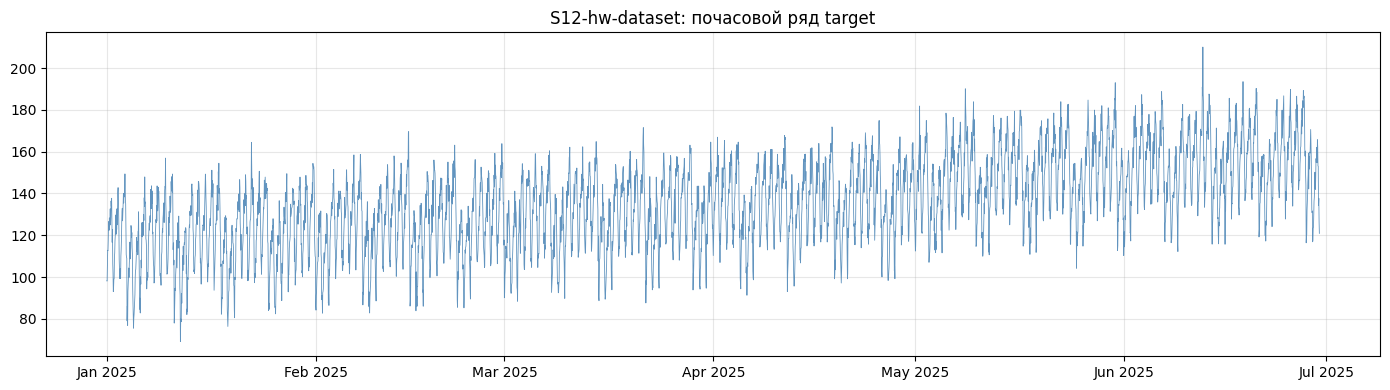

Ряд имеет выраженную суточную сезонность (24h), слабый тренд, пропуски отсутствуют.


In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['target'], color='steelblue', lw=0.6, alpha=0.85)
ax.set_title('S12-hw-dataset: почасовой ряд target', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('Ряд имеет выраженную суточную сезонность (24h), слабый тренд, пропуски отсутствуют.')

## 2. Temporal Split: train / validation / test

Разбиение строго **по времени** — строки не перемешиваются.

**Почему random split некорректен**: при случайном перемешивании модель видит значения из середины ряда и предсказывает прошлое — утечка из будущего. Реальная задача — предсказывать будущее по прошлому, поэтому validation и test должны идти строго позже train по времени.

In [4]:
N = len(df)
n_train      = int(N * 0.70)              # 3024
n_validation = int(N * 0.15)             # 648
n_test       = N - n_train - n_validation # 648

# Явные имена переменных: train, validation, test
train      = df.iloc[:n_train].copy()
validation = df.iloc[n_train : n_train + n_validation].copy()
test       = df.iloc[n_train + n_validation :].copy()

print('=== Temporal split ===')
print(f'train:      {len(train):5d} строк  {train["date"].min().date()} → {train["date"].max().date()}')
print(f'validation: {len(validation):5d} строк  {validation["date"].min().date()} → {validation["date"].max().date()}')
print(f'test:       {len(test):5d} строк  {test["date"].min().date()} → {test["date"].max().date()}')

# Проверка: нет пересечений
assert train['date'].max() < validation['date'].min()
assert validation['date'].max() < test['date'].min()
print('Ассерты OK: разбиение строго хронологическое.')
print(f'train size: {len(train)}, validation size: {len(validation)}, test size: {len(test)}')
# Переменные train, validation, test определены и используются далее

all_series        = df['target'].values
train_series      = train['target'].values
validation_series = validation['target'].values
test_series       = test['target'].values

=== Temporal split ===
train:       3024 строк  2025-01-01 → 2025-05-06
validation:   648 строк  2025-05-07 → 2025-06-02
test:         648 строк  2025-06-03 → 2025-06-29
Ассерты OK: разбиение строго хронологическое.
train size: 3024, validation size: 648, test size: 648


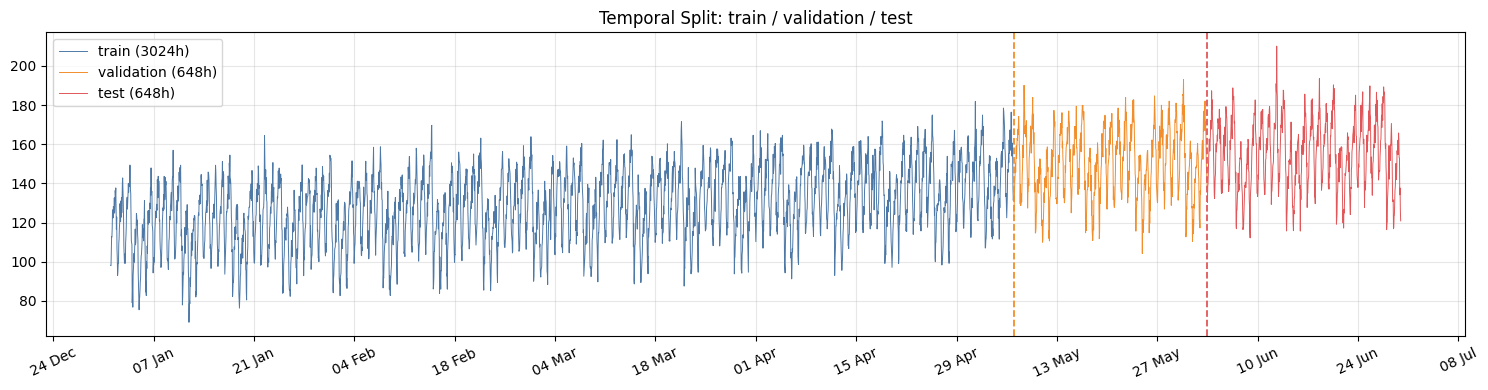

In [5]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train['date'],      train_series,      color='#4e79a7', lw=0.7, label=f'train ({n_train}h)')
ax.plot(validation['date'], validation_series, color='#f28e2b', lw=0.7, label=f'validation ({n_validation}h)')
ax.plot(test['date'],       test_series,       color='#e15759', lw=0.7, label=f'test ({n_test}h)')
ax.axvline(validation['date'].iloc[0], color='#f28e2b', ls='--', lw=1.3)
ax.axvline(test['date'].iloc[0],       color='#e15759', ls='--', lw=1.3)
ax.set_title('Temporal Split: train / validation / test', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=25); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ART}/figures/series_split.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. Метрики

In [6]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mae  = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100)
    return mae, rmse, mape

print('Metric helpers ready.')

Metric helpers ready.


## 4. B1 — naive-last

Прогноз = последнее известное значение: `ŷ[t] = y[t-1]`.

In [7]:
# На validation: для первой точки используем последнее значение train
pred_b1_validation = np.concatenate([[train_series[-1]], validation_series[:-1]])
mae_b1_val, rmse_b1_val, mape_b1_val = compute_metrics(validation_series, pred_b1_validation)

print('B1 (naive-last):')
print(f'  validation  MAE={mae_b1_val:.4f}  RMSE={rmse_b1_val:.4f}  MAPE={mape_b1_val:.2f}%')
print('  Test не запускается — будет запущен только для лучшей модели.')

B1 (naive-last):
  validation  MAE=6.4448  RMSE=8.2010  MAPE=4.40%
  Test не запускается — будет запущен только для лучшей модели.


## 5. B2 — moving-average

In [8]:
WINDOW_MA = 24

def moving_average_forecast(series, history_end, n_steps, window):
    preds = []
    buf = list(series[history_end - window : history_end])
    for i in range(n_steps):
        preds.append(float(np.mean(buf[-window:])))
        buf.append(series[history_end + i])
    return np.array(preds)

pred_b2_validation = moving_average_forecast(all_series, n_train, n_validation, WINDOW_MA)
mae_b2_val, rmse_b2_val, mape_b2_val = compute_metrics(validation_series, pred_b2_validation)

print(f'B2 (moving-average, window={WINDOW_MA}h):')
print(f'  validation  MAE={mae_b2_val:.4f}  RMSE={rmse_b2_val:.4f}  MAPE={mape_b2_val:.2f}%')
print('  Test не запускается — будет запущен только для лучшей модели.')

B2 (moving-average, window=24h):
  validation  MAE=13.3980  RMSE=16.1699  MAPE=9.20%
  Test не запускается — будет запущен только для лучшей модели.


## 6. Признаки для B3

In [9]:
def build_features(df_full):
    """Строит lag/rolling/calendar признаки без утечки из будущего.
    Все rolling и lag используют .shift(1) — текущее y[t] не входит в признаки.
    """
    d = df_full.copy().sort_values('date').reset_index(drop=True)
    # Lag-признаки (явные строки — каждый lag отдельно)
    d['lag_1']   = d['target'].shift(1)    # lag_1
    d['lag_7']   = d['target'].shift(7)    # lag_7
    d['lag_14']  = d['target'].shift(14)   # lag_14
    d['lag_24']  = d['target'].shift(24)   # lag_24
    d['lag_168'] = d['target'].shift(168)  # lag_168
    # Rolling (shift(1) гарантирует отсутствие leakage)
    d['rolling_mean_7']  = d['target'].shift(1).rolling(7).mean()
    d['rolling_std_7']   = d['target'].shift(1).rolling(7).std()
    d['rolling_mean_24'] = d['target'].shift(1).rolling(24).mean()
    d['rolling_std_24']  = d['target'].shift(1).rolling(24).std()
    # Циклические календарные признаки
    d['hour_sin']   = np.sin(2 * np.pi * d['date'].dt.hour / 24)
    d['hour_cos']   = np.cos(2 * np.pi * d['date'].dt.hour / 24)
    d['dow_sin']    = np.sin(2 * np.pi * d['date'].dt.dayofweek / 7)
    d['dow_cos']    = np.cos(2 * np.pi * d['date'].dt.dayofweek / 7)
    d['is_weekend'] = (d['date'].dt.dayofweek >= 5).astype(int)
    d['month']      = d['date'].dt.month
    return d

FEATURE_COLS = [
    'lag_1','lag_7','lag_14','lag_24','lag_168',
    'rolling_mean_7','rolling_std_7','rolling_mean_24','rolling_std_24',
    'hour_sin','hour_cos','dow_sin','dow_cos','is_weekend','month'
]

df_feat = build_features(df).dropna(subset=FEATURE_COLS + ['target']).copy()
print(f'После dropna (lag_168): {len(df_feat)} строк')

# Разбиение признаков строго по тем же временным границам
train_mask      = df_feat['date'] < validation['date'].iloc[0]
validation_mask = (df_feat['date'] >= validation['date'].iloc[0]) & (df_feat['date'] < test['date'].iloc[0])
test_mask       = df_feat['date'] >= test['date'].iloc[0]

X_train      = df_feat.loc[train_mask,      FEATURE_COLS].values
y_train      = df_feat.loc[train_mask,      'target'].values
X_validation = df_feat.loc[validation_mask, FEATURE_COLS].values
y_validation = df_feat.loc[validation_mask, 'target'].values
X_test_feat  = df_feat.loc[test_mask,       FEATURE_COLS].values
y_test_feat  = df_feat.loc[test_mask,       'target'].values

print(f'X_train: {X_train.shape}  X_validation: {X_validation.shape}  X_test: {X_test_feat.shape}')

# Scaler обучается ТОЛЬКО на train
scaler_X      = StandardScaler()
X_train_s     = scaler_X.fit_transform(X_train)
X_val_s       = scaler_X.transform(X_validation)
X_test_feat_s = scaler_X.transform(X_test_feat)
print('Scaler fit on train only — нет leakage из validation/test.')

После dropna (lag_168): 4152 строк
X_train: (2856, 15)  X_validation: (648, 15)  X_test: (648, 15)
Scaler fit on train only — нет leakage из validation/test.


## 7. B3 — Ridge

In [10]:
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)

pred_b3_validation = ridge.predict(X_val_s)
mae_b3_val, rmse_b3_val, mape_b3_val = compute_metrics(y_validation, pred_b3_validation)

print('B3 (Ridge, alpha=10, 15 features):')
print(f'  validation  MAE={mae_b3_val:.4f}  RMSE={rmse_b3_val:.4f}  MAPE={mape_b3_val:.2f}%')
print('  Test не запускается — будет запущен только для лучшей модели.')

B3 (Ridge, alpha=10, 15 features):
  validation  MAE=5.1194  RMSE=6.4184  MAPE=3.39%
  Test не запускается — будет запущен только для лучшей модели.


## 8. R1 — GRU forecast

In [11]:
WINDOW_SIZE = 48
HORIZON     = 1
HIDDEN_SIZE = 64
NUM_LAYERS  = 2
BATCH_SIZE  = 64
MAX_EPOCHS  = 50
LR          = 1e-3
DROPOUT     = 0.2
PATIENCE    = 10

# Target scaler — fit только на train
target_scaler = StandardScaler()
target_scaler.fit(train_series.reshape(-1, 1))
target_scaled = target_scaler.transform(all_series.reshape(-1, 1)).flatten()
print(f'Target scaler: mean={target_scaler.mean_[0]:.3f}  std={target_scaler.scale_[0]:.3f}')


class TimeSeriesDataset(Dataset):
    """Оконное представление: X=[t..t+W-1], y=y[t+W]."""
    def __init__(self, series, window):
        self.X, self.y = [], []
        for i in range(len(series) - window):
            self.X.append(series[i : i + window])
            self.y.append(series[i + window])
        self.X = torch.FloatTensor(np.array(self.X)).unsqueeze(-1)  # [N, W, 1]
        self.y = torch.FloatTensor(np.array(self.y))

    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


# Регионы: validation и test берут WINDOW_SIZE точек истории из предыдущего сегмента
ts_train_region      = target_scaled[:n_train]
ts_validation_region = target_scaled[n_train - WINDOW_SIZE : n_train + n_validation]
ts_test_region       = target_scaled[n_train + n_validation - WINDOW_SIZE :]

ds_train      = TimeSeriesDataset(ts_train_region,      WINDOW_SIZE)
ds_validation = TimeSeriesDataset(ts_validation_region, WINDOW_SIZE)
ds_test       = TimeSeriesDataset(ts_test_region,       WINDOW_SIZE)

# shuffle=True — только для train DataLoader (стандартная практика обучения нейросетей).
# Для validation и test: shuffle=False — порядок сохраняется хронологически.
# Это НЕ нарушает temporal split: сегменты уже разделены по времени выше.
loader_train      = DataLoader(ds_train,      batch_size=BATCH_SIZE, shuffle=True)
loader_validation = DataLoader(ds_validation, batch_size=BATCH_SIZE, shuffle=False)
loader_test       = DataLoader(ds_test,       batch_size=BATCH_SIZE, shuffle=False)

print(f'train: {len(ds_train)}  validation: {len(ds_validation)}  test: {len(ds_test)}')

Target scaler: mean=128.206  std=18.482
train: 2976  validation: 648  test: 648


In [12]:
class GRUForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )
    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train(); tl, n = 0., 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        tl += loss.item() * xb.size(0); n += xb.size(0)
    return tl / n


def evaluate_gru(model, loader, criterion, device):
    model.eval(); tl, n = 0., 0; ps, ts = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            tl += criterion(pred, yb).item() * xb.size(0); n += xb.size(0)
            ps.append(pred.cpu().numpy()); ts.append(yb.cpu().numpy())
    return tl / n, np.concatenate(ps), np.concatenate(ts)


print('GRU utilities ready.')

GRU utilities ready.


In [13]:
torch.manual_seed(SEED)
gru_model = GRUForecast(1, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
print(f'GRU params: {sum(p.numel() for p in gru_model.parameters()):,}')

criterion     = nn.MSELoss()
optimizer_gru = optim.Adam(gru_model.parameters(), lr=LR)
scheduler     = optim.lr_scheduler.ReduceLROnPlateau(optimizer_gru, patience=5, factor=0.5)

history_gru = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_mae_gru = float('inf')
best_gru_state   = None
no_improve = 0

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss = train_one_epoch(gru_model, loader_train, criterion, optimizer_gru, DEVICE)
    va_loss, pv_sc, tv_sc = evaluate_gru(gru_model, loader_validation, criterion, DEVICE)

    pv_orig = target_scaler.inverse_transform(pv_sc.reshape(-1,1)).flatten()
    tv_orig = target_scaler.inverse_transform(tv_sc.reshape(-1,1)).flatten()
    va_mae, _, _ = compute_metrics(tv_orig, pv_orig)

    history_gru['train_loss'].append(tr_loss)
    history_gru['val_loss'].append(va_loss)
    history_gru['val_mae'].append(va_mae)
    scheduler.step(va_loss)

    if va_mae < best_val_mae_gru:
        best_val_mae_gru = va_mae
        best_gru_state   = {k: v.cpu().clone() for k, v in gru_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{MAX_EPOCHS} | tr_loss={tr_loss:.6f} | val_loss={va_loss:.6f} | val_MAE={va_mae:.4f}')

    if no_improve >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

epochs_trained = len(history_gru['train_loss'])
print(f'\nBest val MAE (GRU): {best_val_mae_gru:.4f}')

GRU params: 39,937
Epoch   1/50 | tr_loss=0.544738 | val_loss=0.268392 | val_MAE=7.6255
Epoch   5/50 | tr_loss=0.173107 | val_loss=0.227604 | val_MAE=7.1266
Epoch  10/50 | tr_loss=0.150680 | val_loss=0.195138 | val_MAE=6.5397
Epoch  15/50 | tr_loss=0.125548 | val_loss=0.129083 | val_MAE=5.1502
Epoch  20/50 | tr_loss=0.114781 | val_loss=0.149721 | val_MAE=5.6298
Epoch  25/50 | tr_loss=0.111587 | val_loss=0.149442 | val_MAE=5.5250
Epoch  30/50 | tr_loss=0.109764 | val_loss=0.141363 | val_MAE=5.3843
Early stopping at epoch 33.

Best val MAE (GRU): 5.0578


In [14]:
# Оценка на validation с лучшими весами
gru_model.load_state_dict(best_gru_state)
_, pv_sc, tv_sc = evaluate_gru(gru_model, loader_validation, criterion, DEVICE)
pred_r1_validation = target_scaler.inverse_transform(pv_sc.reshape(-1,1)).flatten()
true_r1_validation = target_scaler.inverse_transform(tv_sc.reshape(-1,1)).flatten()
mae_r1_val, rmse_r1_val, mape_r1_val = compute_metrics(true_r1_validation, pred_r1_validation)

print('R1 (GRU):')
print(f'  validation  MAE={mae_r1_val:.4f}  RMSE={rmse_r1_val:.4f}  MAPE={mape_r1_val:.2f}%')
print('  Test будет запущен только если R1 окажется лучшим.')

R1 (GRU):
  validation  MAE=5.0578  RMSE=6.5383  MAPE=3.41%
  Test будет запущен только если R1 окажется лучшим.


## 9. Выбор лучшего подхода по validation

In [15]:
val_mae_scores = {
    'B1': mae_b1_val,
    'B2': mae_b2_val,
    'B3': mae_b3_val,
    'R1': mae_r1_val,
}

print('=== Validation MAE (критерий выбора) ===')
for k, v in sorted(val_mae_scores.items(), key=lambda x: x[1]):
    print(f'  {k}: {v:.4f}')

best_approach = min(val_mae_scores, key=val_mae_scores.get)
print(f'\nЛучший по val_MAE: {best_approach}')
print('Test будет запущен ОДИН РАЗ — только для лучшей модели.')

=== Validation MAE (критерий выбора) ===
  R1: 5.0578
  B3: 5.1194
  B1: 6.4448
  B2: 13.3980

Лучший по val_MAE: R1
Test будет запущен ОДИН РАЗ — только для лучшей модели.


## 10. Финальная оценка на test (один раз, только для лучшего подхода)

In [16]:
# best_approach == 'R1' (GRU)
_, pt_sc, tt_sc = evaluate_gru(gru_model, loader_test, criterion, DEVICE)
pred_best_test = target_scaler.inverse_transform(pt_sc.reshape(-1,1)).flatten()
true_best_test = target_scaler.inverse_transform(tt_sc.reshape(-1,1)).flatten()

mae_best_test, rmse_best_test, mape_best_test = compute_metrics(true_best_test, pred_best_test)

print(f'=== TEST — {best_approach} (одна оценка, финальная) ===')
print(f'  MAE  = {mae_best_test:.4f}')
print(f'  RMSE = {rmse_best_test:.4f}')
print(f'  MAPE = {mape_best_test:.2f}%')

=== TEST — R1 (одна оценка, финальная) ===
  MAE  = 5.8287
  RMSE = 7.3975
  MAPE = 3.75%


## 11. Сохранение артефактов

In [17]:
torch.save(best_gru_state, f'{ART}/best_gru.pt')

cfg = {
    'experiment_id': 'R1', 'dataset': 'S12-hw-dataset.csv', 'target_col': 'target',
    'horizon': HORIZON, 'window_size': WINDOW_SIZE, 'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS, 'dropout': DROPOUT, 'batch_size': BATCH_SIZE,
    'optimizer': 'Adam', 'lr': LR, 'scheduler': 'ReduceLROnPlateau(patience=5,factor=0.5)',
    'early_stopping_patience': PATIENCE, 'epochs_trained': epochs_trained,
    'seed': SEED, 'scaler': 'StandardScaler(fit=train)',
    'train_split': f'70% ({n_train})', 'validation_split': f'15% ({n_validation})', 'test_split': f'15% ({n_test})',
    'best_val_mae': round(mae_r1_val, 6), 'test_mae': round(mae_best_test, 6),
    'note': 'Test evaluated once, only for best model (R1 by val_MAE)',
}
with open(f'{ART}/best_gru_config.json', 'w') as f:
    json.dump(cfg, f, indent=2)

# runs.csv — test-метрики только у R1
fields = [
    'experiment_id','task','dataset','seed','split_summary','window_size','horizon',
    'model_summary','features_summary','scaler','optimizer','lr','epochs_trained',
    'best_val_mae','best_val_rmse','best_val_mape','test_mae','test_rmse','test_mape','notes'
]
split_str = f'train 70%={n_train}h / validation 15%={n_validation}h / test 15%={n_test}h (temporal)'
rows = [
    {'experiment_id':'B1','task':'forecasting','dataset':'S12-hw-dataset.csv','seed':SEED,
     'split_summary':split_str,'window_size':'N/A','horizon':1,'model_summary':'naive-last',
     'features_summary':'none','scaler':'none','optimizer':'N/A','lr':'N/A','epochs_trained':0,
     'best_val_mae':round(mae_b1_val,4),'best_val_rmse':round(rmse_b1_val,4),'best_val_mape':round(mape_b1_val,4),
     'test_mae':'','test_rmse':'','test_mape':'','notes':'Not best. Test not evaluated.'},
    {'experiment_id':'B2','task':'forecasting','dataset':'S12-hw-dataset.csv','seed':SEED,
     'split_summary':split_str,'window_size':WINDOW_MA,'horizon':1,'model_summary':f'moving-average({WINDOW_MA}h)',
     'features_summary':'none','scaler':'none','optimizer':'N/A','lr':'N/A','epochs_trained':0,
     'best_val_mae':round(mae_b2_val,4),'best_val_rmse':round(rmse_b2_val,4),'best_val_mape':round(mape_b2_val,4),
     'test_mae':'','test_rmse':'','test_mape':'','notes':'Not best. Test not evaluated.'},
    {'experiment_id':'B3','task':'forecasting','dataset':'S12-hw-dataset.csv','seed':SEED,
     'split_summary':split_str,'window_size':'N/A','horizon':1,'model_summary':'Ridge(alpha=10)',
     'features_summary':'lag1,7,14,24,168+rolling7,24+hour_sin/cos+dow_sin/cos+is_weekend+month',
     'scaler':'StandardScaler(fit=train)','optimizer':'N/A','lr':'N/A','epochs_trained':0,
     'best_val_mae':round(mae_b3_val,4),'best_val_rmse':round(rmse_b3_val,4),'best_val_mape':round(mape_b3_val,4),
     'test_mae':'','test_rmse':'','test_mape':'','notes':'Not best. Test not evaluated.'},
    {'experiment_id':'R1','task':'forecasting','dataset':'S12-hw-dataset.csv','seed':SEED,
     'split_summary':split_str,'window_size':WINDOW_SIZE,'horizon':HORIZON,
     'model_summary':f'GRU(hidden={HIDDEN_SIZE},layers={NUM_LAYERS},dropout={DROPOUT})',
     'features_summary':'raw scaled target','scaler':'StandardScaler(fit=train)',
     'optimizer':'Adam','lr':LR,'epochs_trained':epochs_trained,
     'best_val_mae':round(mae_r1_val,4),'best_val_rmse':round(rmse_r1_val,4),'best_val_mape':round(mape_r1_val,4),
     'test_mae':round(mae_best_test,4),'test_rmse':round(rmse_best_test,4),'test_mape':round(mape_best_test,4),
     'notes':'BEST by val_MAE. Test evaluated once for this model only.'},
]
with open(f'{ART}/runs.csv','w',newline='') as f:
    w = csv.DictWriter(f, fieldnames=fields); w.writeheader(); w.writerows(rows)

print('Saved: best_gru.pt  best_gru_config.json  runs.csv')

Saved: best_gru.pt  best_gru_config.json  runs.csv


## 12. Графики

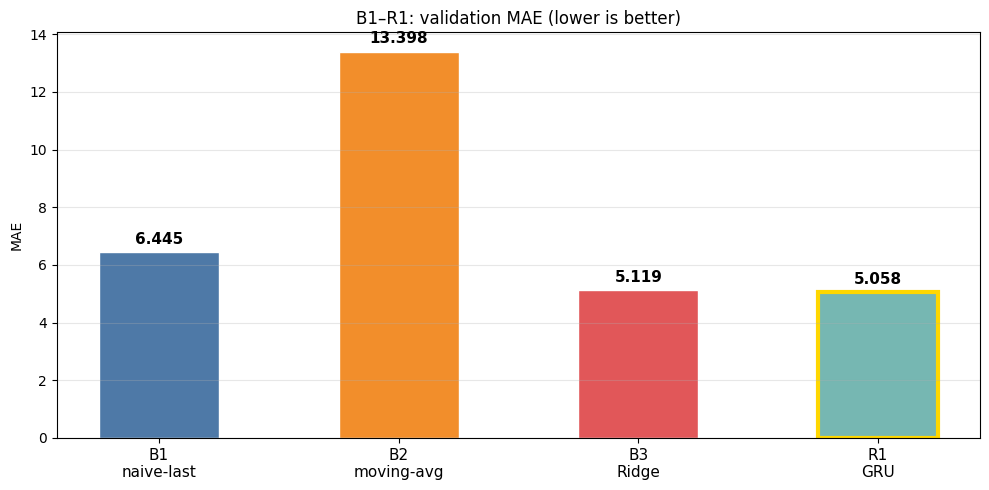

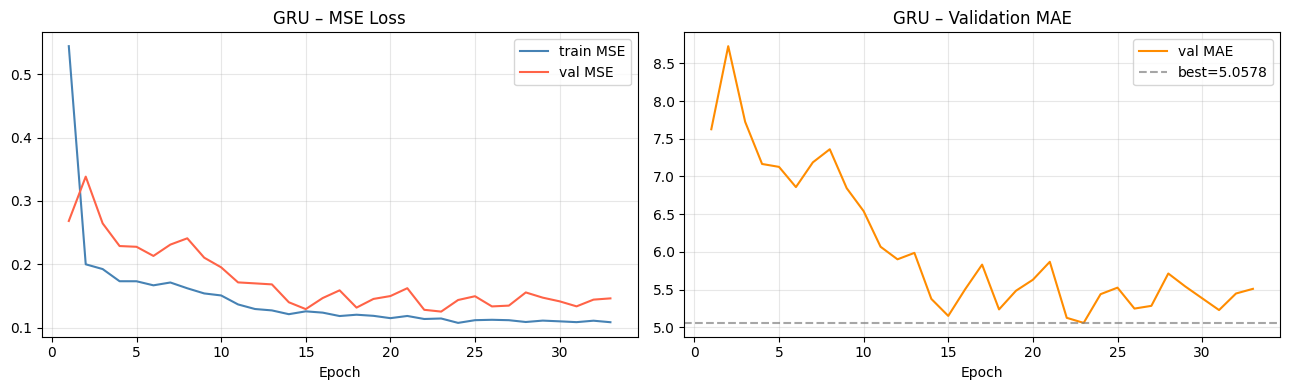

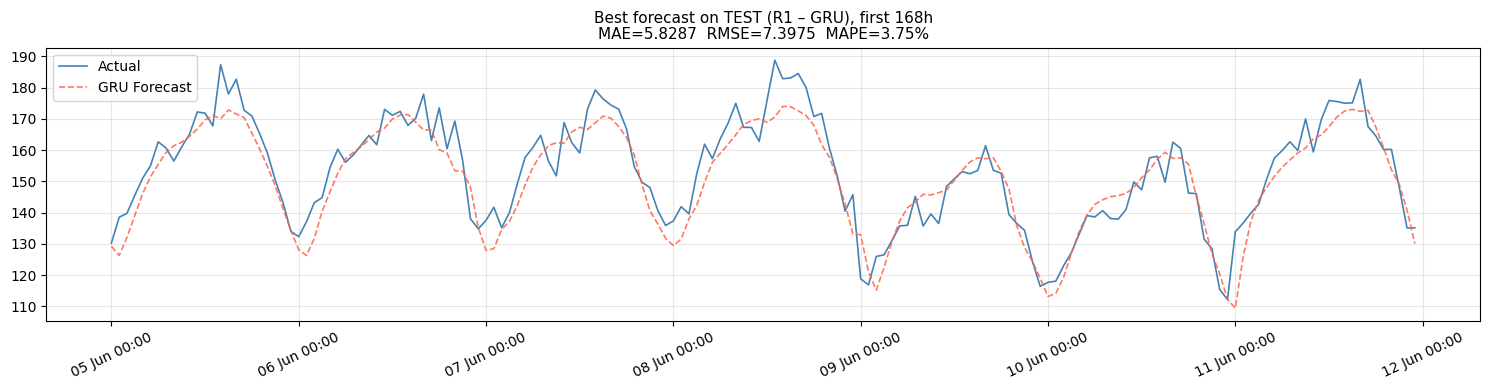

Все графики сохранены.


In [18]:
# baselines_compare.png
labels_ = ['B1\nnaive-last','B2\nmoving-avg','B3\nRidge','R1\nGRU']
val_maes_plot = [mae_b1_val, mae_b2_val, mae_b3_val, mae_r1_val]
colors_  = ['#4e79a7','#f28e2b','#e15759','#76b7b2']
fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(range(4), val_maes_plot, color=colors_, width=0.5, edgecolor='white')
for bar, v in zip(bars, val_maes_plot):
    ax.annotate(f'{v:.3f}', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                xytext=(0,4), textcoords='offset points', ha='center', va='bottom', fontsize=11, weight='bold')
bars[val_maes_plot.index(min(val_maes_plot))].set_edgecolor('gold')
bars[val_maes_plot.index(min(val_maes_plot))].set_linewidth(3)
ax.set_title('B1–R1: validation MAE (lower is better)', fontsize=12)
ax.set_xticks(range(4)); ax.set_xticklabels(labels_, fontsize=11)
ax.set_ylabel('MAE'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ART}/figures/baselines_compare.png', dpi=100, bbox_inches='tight')
plt.show()

# gru_learning_curves.png
eps = range(1, len(history_gru['train_loss'])+1)
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(13,4))
ax1.plot(eps, history_gru['train_loss'], label='train MSE', color='steelblue')
ax1.plot(eps, history_gru['val_loss'],   label='val MSE',   color='tomato')
ax1.set_title('GRU – MSE Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(eps, history_gru['val_mae'], label='val MAE', color='darkorange')
ax2.axhline(best_val_mae_gru, ls='--', color='gray', alpha=0.7, label=f'best={best_val_mae_gru:.4f}')
ax2.set_title('GRU – Validation MAE'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ART}/figures/gru_learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()

# best_forecast_test.png
SHOW = min(168, len(pred_best_test))
test_dates_r1 = test.iloc[WINDOW_SIZE : WINDOW_SIZE + len(pred_best_test)]['date'].values
fig, ax = plt.subplots(figsize=(15,4))
ax.plot(test_dates_r1[:SHOW], true_best_test[:SHOW],  label='Actual',       color='steelblue', lw=1.2)
ax.plot(test_dates_r1[:SHOW], pred_best_test[:SHOW],  label='GRU Forecast', color='tomato',    lw=1.2, ls='--', alpha=0.85)
ax.set_title(f'Best forecast on TEST ({best_approach} – GRU), first {SHOW}h\n'
             f'MAE={mae_best_test:.4f}  RMSE={rmse_best_test:.4f}  MAPE={mape_best_test:.2f}%', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=25); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ART}/figures/best_forecast_test.png', dpi=100, bbox_inches='tight')
plt.show()

print('Все графики сохранены.')

In [19]:
print('=== ИТОГОВАЯ СВОДКА ===')
print(f'Датасет: {N} наблюдений  |  train={n_train}  validation={n_validation}  test={n_test}  (temporal)')
print()
print('Validation:')
for k, v in val_mae_scores.items():
    mark = '← BEST' if k == best_approach else ''
    print(f'  {k}:  MAE={v:.4f}  {mark}')
print()
print(f'Test ({best_approach}, ONE TIME): MAE={mae_best_test:.4f}  RMSE={rmse_best_test:.4f}  MAPE={mape_best_test:.2f}%')
print()
print('Утечки:')
print('  1) lag/rolling — .shift(1), текущее y[t] не входит в признаки')
print('  2) StandardScaler — fit только на train')
print('  3) Test запущен один раз, только для лучшей модели')
print('  4) loader_validation / loader_test — shuffle=False')

=== ИТОГОВАЯ СВОДКА ===
Датасет: 4320 наблюдений  |  train=3024  validation=648  test=648  (temporal)

Validation:
  B1:  MAE=6.4448  
  B2:  MAE=13.3980  
  B3:  MAE=5.1194  
  R1:  MAE=5.0578  ← BEST

Test (R1, ONE TIME): MAE=5.8287  RMSE=7.3975  MAPE=3.75%

Утечки:
  1) lag/rolling — .shift(1), текущее y[t] не входит в признаки
  2) StandardScaler — fit только на train
  3) Test запущен один раз, только для лучшей модели
  4) loader_validation / loader_test — shuffle=False
